In [1]:
from test_nuradio_single import NuRadioRecoReader
from NuRadioReco.detector import detector
from NuRadioReco.detector.SKA.detector import Detector as SKADetector
from NuRadioReco.utilities import units
from NuRadioReco.detector.antennapattern import preprocess_LOFAR_txt
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import os

ERROR - 2026-08-10 15:58:18,260 - NuRadioReco.channelGalacticNoiseAdder - pylfmap import failed. This might be because you do not have a working installation of cfitsio. See https://github.com/F-Tomas/pylfmap/issues/2 for potential tips


In [ ]:
def calc_rms(trace, length):
    return np.sqrt(np.mean(np.square(trace[:-length])))

def remove_signal(trace, sig_window, rms, threshold):
    if np.max(trace)/rms > threshold:
        sig = np.argmax(trace)
        return np.delete(trace, np.arange(sig-sig_window,sig+sig_window+1)), True
    return trace, False

def get_reals(traces, dur, sig_window, rms, threshold):
    reals = []
    n_removed = 0
    for trace in traces:
        new, rem = remove_signal(trace, sig_window, rms, threshold)
        to_consider = new[:-(len(new)%dur)]
        reals.append(np.split(to_consider, len(to_consider)/dur))
        if rem:
            n_removed += 1
        
    print(f"{n_removed}/{len(traces)} had above SNR {threshold} signal", flush=True)
    # with open(fn_time, 'a') as f:
    #     f.write(f"{n_removed}/{len(traces)} had above SNR {threshold} signal \n")

    return np.vstack(reals)

def make_cov(traces, duration, sig_window, rms_window, threshold):
    rms = calc_rms(traces[0], rms_window)
    reals = np.array(get_reals(traces, duration, sig_window, rms, threshold))
    N = len(reals)

    if N==0:
        return np.zeros((duration, duration)), N

    return np.cov(reals.T), N

def draw_cov(cov, N, dur, display_bin, evt_name, dirname):
    # Make plots
    plt.figure()
    sns.heatmap(cov, xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
    plt.suptitle(evt_name)
    plt.title(f"Size: {dur} ({dur*1.2} ns), {N} realizations")
    plt.tight_layout()

    fn = os.path.join(dirname, "cov.png")
    plt.savefig(fn, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    plt.figure()
    sns.heatmap(cov[:display_bin, :display_bin], xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
    plt.suptitle(f"{evt_name}; First {display_bin} bins")
    plt.title(f"Size: {dur} ({dur*1.2} ns), {N} realizations")
    plt.tight_layout()

    fn = os.path.join(dirname, f"cov_{display_bin}.png")
    plt.savefig(fn, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    

def draw_1D(cov, x_time, dur, display_bin, evt_name, dirname, m=False):

    rows, cols = cov.shape
    col_indices = (np.arange(rows)[:, None] + np.arange(cols)) % cols
    small_cov = cov[np.arange(rows)[:, None], col_indices][:, :display_bin]
    
    small_x = x_time[:display_bin]

    # First Row
    plt.figure(figsize=(12,6))
    plt.axhline(y=0, c="gray", linestyle="--")
    plt.plot(small_x, small_cov[0])
    plt.scatter(small_x, small_cov[0], marker=".")

    plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
    plt.ylabel(r"Cov($\Delta t_{i,j}$)")
    
    plt.suptitle(evt_name)
    plt.title(f"1D function of the first row for first {display_bin} bins. Size: {dur} ({dur*1.2} ns), {N} realizations")
    plt.tight_layout()

    fn = os.path.join(dirname, "1d.pdf")
    plt.savefig(fn, format="pdf")
    plt.show()
    plt.close()

    # Calculate Std
    mean = np.mean(small_cov, axis=0)
    stds = np.std(small_cov, axis=0)

    # Non-Normalized 1 sigma
    plt.figure(figsize=(12,6))
    plt.axhline(y=0, c="gray", linestyle="--")
    plt.fill_between(small_x, mean-stds, mean+stds, color="tab:blue", alpha=0.5)
    if m:
        plt.plot(small_x, mean, c="red", label="mean")
    plt.plot(small_x, small_cov[0], c="tab:blue", marker=".", label="First Row")
    plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
    plt.ylabel(r"Cov($\Delta t_{i,j}$)")
    
    plt.suptitle(evt_name)
    plt.title(f"1D function for first {display_bin} bins. Size: {dur} ({dur*1.2} ns), {N} realizations")
    plt.tight_layout()

    fn = os.path.join(dirname, "1d_unc.pdf")
    plt.savefig(fn, format="pdf")
    plt.show()
    plt.close()

    # NOrmalized 1 sigma
    small_cov /= np.max(small_cov, axis=1)[:, None]
    mean = np.mean(small_cov, axis=0)
    stds = np.std(small_cov, axis=0)

    plt.figure(figsize=(12,6))
    plt.axhline(y=0, c="gray", linestyle="--")
    plt.fill_between(small_x, mean-stds, mean+stds, color="tab:blue", alpha=0.5)
    if m:
        plt.plot(small_x, mean, c="red", label="mean")
    plt.plot(small_x, small_cov[0], c="tab:blue", marker=".", label="First Row")

    plt.xlabel(r"$\Delta t_{i,j}$ [ns]")
    plt.ylabel(r"Normalized Cov($\Delta t_{i,j}$)")

    plt.legend()
    plt.suptitle(evt_name)
    plt.title(f"Normalized 1D function for first {display_bin} bins. Size: {dur} ({dur*1.2} ns), {N} realizations")
    plt.tight_layout()

    fn = os.path.join(dirname, "1d_unc_norm.pdf")
    plt.savefig(fn, format="pdf")
    plt.show()
    plt.close()

In [3]:
path_to_response = "/home/rkitahara/Research/Cov/test_simulation/antenna_response_lofar"
# path_to_response = "/home/rkitahara/Research/Cov/SKA_Cov/antenna_response_ska/Vogel/telescope.tm"

path_to_coreas_sim_file = "/home/rkitahara/Research/Cov/test_simulation/93970574/0/proton/SIM000018.hdf5"

det = detector.Detector(
    "LOFAR/LOFAR.json", source="json", antenna_by_depth=False
)
# det = SKADetector(position_path=path_to_response, maximum_radius=30 * units.m)
det.update(datetime.datetime(2013, 1, 1, 0, 0, 0))

selected_station_channel_ids = {}
for staid in [1]:
    selected_station_channel_ids[staid] = det.get_channel_ids(staid)[:2]
# decimation = 200
# for staid in det.get_station_ids():
#     selected_station_channel_ids[staid] = np.sort(np.concatenate([det.get_channel_ids(staid)[0::2][::decimation],
#                                                                     det.get_channel_ids(staid)[1::2][::decimation]]))

core_xy = np.array([0, 0]) * units.m

preprocess_LOFAR_txt(path_to_response, orientation="Y")
preprocess_LOFAR_txt(path_to_response, orientation="X")

In [6]:
reader = NuRadioRecoReader(det,filt_settings={"passband": [30 * units.MHz, 80 * units.MHz], "filter_type": "butter", "order": 10})
traces = []
for i in range(500):
    evt = reader.read_data_event_with_noise(path_to_coreas_sim_file, selected_station_channel_ids=selected_station_channel_ids, core=core_xy, Tnoise=200 * units.K)
    traces.append(evt.get_station(1).get_channel(evt.get_station(1).get_channel_ids()[0]).get_trace()[::50])
    traces.append(evt.get_station(1).get_channel(evt.get_station(1).get_channel_ids()[1]).get_trace()[::50])
traces = np.array(traces)

WARNING - 2026-08-10 15:58:42,082 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 15:58:42,082 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 15:58:42,083 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 15:58:42,087 - NuRadioReco.antennapattern - no hash sum of LOFAR_LBA_Y.pkl available, skipping up-to-date check
STATUS - 2026-08-10 15:58:42,089 - NuRadioReco.antennapattern - Performing consistency check on antenna response ...
STATUS - 2026-08-10 15:58:42,128 - NuRadioReco.antennapattern - Loading antenna file LOFAR_LBA_Y took 0.0 seconds
WARNING - 2026-08-10 15:58:42,132 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 15:58:42,136 - NuRadioReco.antennapattern - no 

Calculated Vrms: 2.63e-06 V, applying noise with amplitude 3.72e-06 V


WARNING - 2026-08-10 15:58:43,963 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 15:58:43,963 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 15:58:43,964 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 15:58:43,966 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero


Calculated Vrms: 2.63e-06 V, applying noise with amplitude 3.72e-06 V


WARNING - 2026-08-10 15:58:45,797 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 15:58:45,797 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 15:58:45,798 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 15:58:45,800 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero


...

WARNING - 2026-08-10 16:05:30,978 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 16:05:30,979 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 16:05:30,979 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 16:05:30,981 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero


Calculated Vrms: 2.63e-06 V, applying noise with amplitude 3.72e-06 V


WARNING - 2026-08-10 16:05:32,841 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 16:05:32,842 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 16:05:32,843 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-10 16:05:32,844 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero


Calculated Vrms: 2.63e-06 V, applying noise with amplitude 3.72e-06 V


KeyboardInterrupt: 

In [ ]:
temp = "200K"
dur = 800
sig_window = 200
noise_window = 50
threshold = 5.
dirname = f"results/LOFAR_{temp}_{len(traces)}samples_size{dur}"
if os.path.exists(dirname) == False:
    os.mkdir(dirname)

cov, N = make_cov(traces, dur, sig_window, noise_window, threshold)

500/1000 had above SNR 5.0 signal


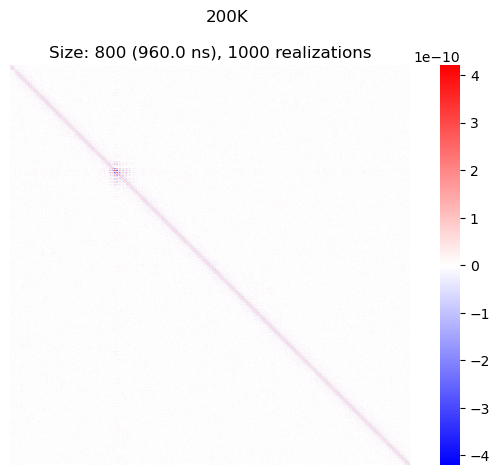

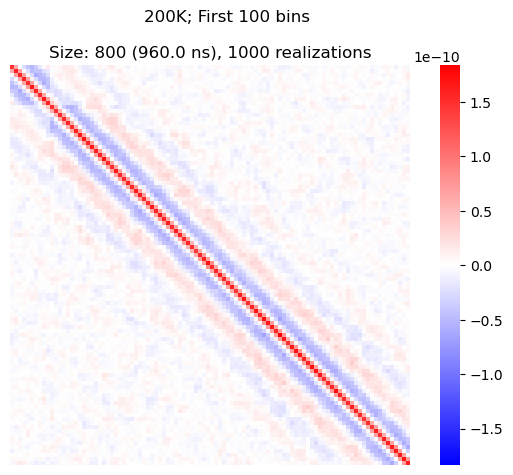

In [6]:
display_bin = 100
draw_cov(cov, N, dur, display_bin, temp, dirname)

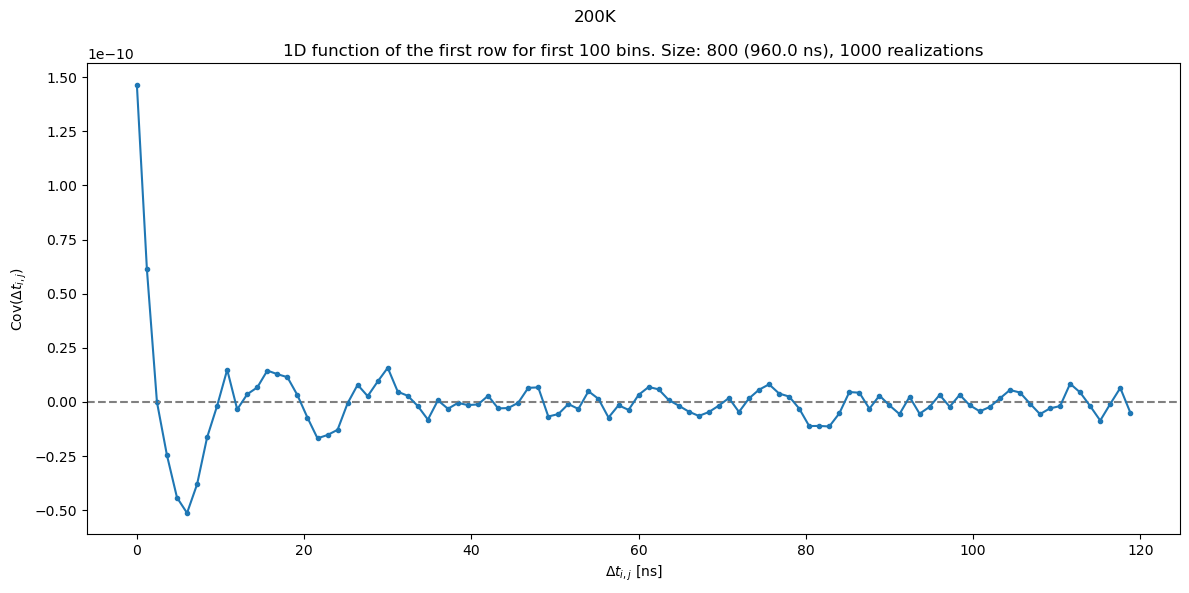

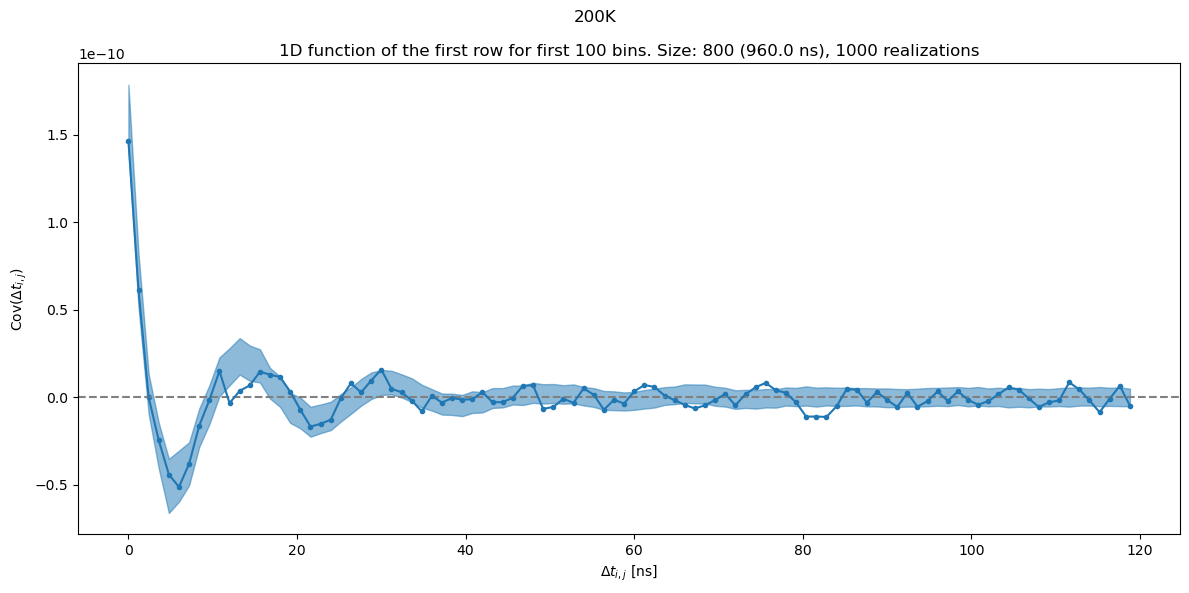

In [ ]:
draw_1D(cov, np.arange(dur)*1.2, dur, display_bin, temp, dirname, True)

In [8]:
np.save(f"{dirname}/traces.npy", traces)
np.save(f"{dirname}/Cov.npy", cov)